# Ch10 - SAC 连续控制

Soft Actor-Critic：最大熵 RL + 双 Q 网络 + 自动温度系数。连续控制 SOTA。

> 本 Notebook 配套《强化学习全面教程》PDF 使用。

In [1]:
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import random
from collections import deque, defaultdict

# 中文字体配置
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__} | 设备: {device} | Gymnasium: {gym.__version__}')


PyTorch: 2.13.0+cpu | 设备: cpu | Gymnasium: 1.3.0


## 10.1 最大熵 RL

标准 RL 最大化期望回报，最大熵 RL 加上熵奖励：
$$J(\pi) = \sum_t E[(r_t + \alpha H(\pi(\cdot|s_t)))]$$

策略既想获得高回报，又想尽可能随机——这种随机性带来更强的探索能力。
$\alpha$ 是温度系数，控制熵权重。

## 10.2 SAC 三大创新

1. **双 Q 网络（Clipped Double Q）**：取 min(Q1, Q2)，抑制 Q 值过估
2. **自动温度系数 α**：让熵接近目标熵（通常 -dim(A)）
3. **重参数化技巧**：a = μ + σ · ε，使采样可微

In [2]:
import copy
import torch.optim as optim
from torch.distributions import Normal
from collections import namedtuple, deque

LOG_STD_MIN, LOG_STD_MAX = -20, 2

class GaussianPolicy(nn.Module):
    """连续动作策略：输出 mean + log_std。"""
    def __init__(self, state_dim, action_dim, hidden=256, action_high=None):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mean = nn.Linear(hidden, action_dim)
        self.log_std = nn.Linear(hidden, action_dim)
        self.action_high = torch.as_tensor(action_high, dtype=torch.float32) if action_high is not None else 1.0

    def forward(self, s):
        h = self.net(s)
        mean = self.mean(h)
        log_std = torch.clamp(self.log_std(h), LOG_STD_MIN, LOG_STD_MAX)
        return mean, log_std.exp()

    def sample(self, s):
        mean, std = self.forward(s)
        dist = Normal(mean, std)
        x = dist.rsample()  # reparameterization
        action = torch.tanh(x) * self.action_high
        log_prob = dist.log_prob(x) - torch.log(1 - torch.tanh(x).pow(2) + 1e-6)
        log_prob = log_prob.sum(dim=-1, keepdim=True)
        return action, log_prob, mean


class QNet(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, s, a):
        return self.net(torch.cat([s, a], dim=-1))


Transition = namedtuple('Transition', ['state', 'action', 'reward', 'next_state', 'done'])
class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buffer = deque(maxlen=capacity)
    def push(self, *args):
        self.buffer.append(Transition(*args))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))
    def __len__(self): return len(self.buffer)

print('SAC 组件定义完成 ✓')

SAC 组件定义完成 ✓


In [3]:
class SACAgent:
    def __init__(self, state_dim, action_dim, action_high, lr=3e-4,
                 gamma=0.99, tau=0.005, alpha=0.2, auto_alpha=True):
        self.device = device
        self.gamma = gamma
        self.tau = tau
        self.action_high = action_high

        # 双 Q
        self.q1 = QNet(state_dim, action_dim).to(device)
        self.q2 = QNet(state_dim, action_dim).to(device)
        self.q1_target = copy.deepcopy(self.q1)
        self.q2_target = copy.deepcopy(self.q2)
        self.q_optim = optim.Adam(list(self.q1.parameters()) + list(self.q2.parameters()), lr=lr)

        # 策略
        self.policy = GaussianPolicy(state_dim, action_dim, action_high=action_high).to(device)
        self.p_optim = optim.Adam(self.policy.parameters(), lr=lr)

        # 自动 α
        self.auto_alpha = auto_alpha
        if auto_alpha:
            self.target_entropy = -action_dim
            self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
            self.alpha_optim = optim.Adam([self.log_alpha], lr=lr)
            self.alpha = self.log_alpha.exp().item()
        else:
            self.alpha = alpha

    def select_action(self, state, eval_mode=False):
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            a, _, mean = self.policy.sample(s)
            return mean.squeeze(0).cpu().numpy() if eval_mode else a.squeeze(0).cpu().numpy()

    def update(self, buffer, batch_size=256):
        if len(buffer) < batch_size: return None
        b = buffer.sample(batch_size)
        s = torch.as_tensor(np.array(b.state), dtype=torch.float32, device=device)
        a = torch.as_tensor(np.array(b.action), dtype=torch.float32, device=device)
        r = torch.as_tensor(b.reward, dtype=torch.float32, device=device).unsqueeze(1)
        s_next = torch.as_tensor(np.array(b.next_state), dtype=torch.float32, device=device)
        done = torch.as_tensor(b.done, dtype=torch.float32, device=device).unsqueeze(1)

        with torch.no_grad():
            a_next, log_p_next, _ = self.policy.sample(s_next)
            q1_next = self.q1_target(s_next, a_next)
            q2_next = self.q2_target(s_next, a_next)
            q_next = torch.min(q1_next, q2_next) - self.alpha * log_p_next
            q_target = r + self.gamma * (1 - done) * q_next

        q1 = self.q1(s, a); q2 = self.q2(s, a)
        q_loss = nn.functional.mse_loss(q1, q_target) + nn.functional.mse_loss(q2, q_target)
        self.q_optim.zero_grad(); q_loss.backward(); self.q_optim.step()

        a_new, log_p_new, _ = self.policy.sample(s)
        q1_new = self.q1(s, a_new); q2_new = self.q2(s, a_new)
        q_new = torch.min(q1_new, q2_new)
        p_loss = (self.alpha * log_p_new - q_new).mean()
        self.p_optim.zero_grad(); p_loss.backward(); self.p_optim.step()

        if self.auto_alpha:
            alpha_loss = -(self.log_alpha * (log_p_new + self.target_entropy).detach()).mean()
            self.alpha_optim.zero_grad(); alpha_loss.backward(); self.alpha_optim.step()
            self.alpha = self.log_alpha.exp().item()

        # 软更新
        for tp, sp in zip(self.q1_target.parameters(), self.q1.parameters()):
            tp.data.copy_(self.tau * sp.data + (1 - self.tau) * tp.data)
        for tp, sp in zip(self.q2_target.parameters(), self.q2.parameters()):
            tp.data.copy_(self.tau * sp.data + (1 - self.tau) * tp.data)
        return q_loss.item()

env = gym.make('Pendulum-v1')
agent = SACAgent(env.observation_space.shape[0], env.action_space.shape[0],
                 float(env.action_space.high[0]))
print('SAC Agent 创建完成 ✓')

SAC Agent 创建完成 ✓


## 10.3 训练循环

Pendulum-v1：连续动作 [-2, 2]，目标让杆立起。SAC 通常 20K 步内可将奖励从 -1600 提升到 -200 左右。

In [4]:
random.seed(42); np.random.seed(42); torch.manual_seed(42)
steps = 20_000  # 可调高到 30_000 获得更优结果
start_steps = 1000
eval_every = 2000

buffer = ReplayBuffer(50_000)
s, _ = env.reset(seed=42)
ep_r, rewards = 0, []
ep_steps = 0

for t in range(steps):
    if t < start_steps:
        a = env.action_space.sample()
    else:
        a = agent.select_action(s)
    s_next, r, terminated, truncated, _ = env.step(a)
    done = terminated or truncated
    buffer.push(s, a, r, s_next, done)
    s = s_next
    ep_r += r; ep_steps += 1
    if done or ep_steps >= 200:
        rewards.append(ep_r)
        s, _ = env.reset(seed=42 + len(rewards))
        ep_r, ep_steps = 0, 0
    if t >= start_steps:
        agent.update(buffer)
    if (t + 1) % eval_every == 0:
        print(f'step {t+1:5d} | 最近10 avg={np.mean(rewards[-10:]):7.2f} '
              f'| α={agent.alpha:.3f} | buf={len(buffer)}')

step  2000 | 最近10 avg=-1377.54 | α=0.744 | buf=2000
step  4000 | 最近10 avg=-1304.67 | α=0.462 | buf=4000
step  6000 | 最近10 avg=-744.91 | α=0.319 | buf=6000
step  8000 | 最近10 avg=-364.03 | α=0.260 | buf=8000
step 10000 | 最近10 avg=-284.61 | α=0.264 | buf=10000
step 12000 | 最近10 avg=-191.53 | α=0.252 | buf=12000
step 14000 | 最近10 avg=-214.39 | α=0.237 | buf=14000
step 16000 | 最近10 avg=-245.76 | α=0.225 | buf=16000
step 18000 | 最近10 avg=-175.65 | α=0.189 | buf=18000
step 20000 | 最近10 avg=-188.15 | α=0.145 | buf=20000


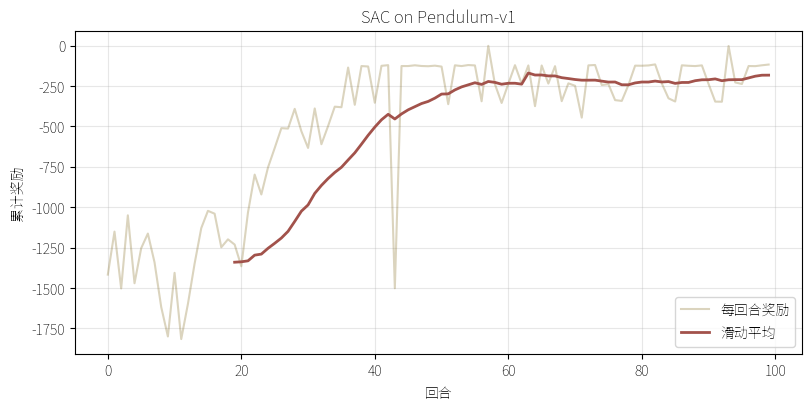

评估回合奖励: -120.7 | 步数: 200


In [5]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(rewards, alpha=0.3, color='#887129', label='每回合奖励')
if len(rewards) >= 20:
    ma = np.convolve(rewards, np.ones(20)/20, mode='valid')
    ax.plot(range(19, len(rewards)), ma, color='#a2524b', linewidth=2, label='滑动平均')
ax.set_xlabel('回合'); ax.set_ylabel('累计奖励')
ax.set_title('SAC on Pendulum-v1')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.show()

# ===== 10.4 策略可视化：摆杆控制动画 =====
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# 用 eval 模式跑一回合，记录每步状态
eval_env = gym.make('Pendulum-v1')
s, _ = eval_env.reset(seed=999)
states, actions, rewards_log = [], [], []
total_r = 0
for t in range(200):
    a = agent.select_action(s, eval_mode=True)
    states.append(s.copy()); actions.append(float(a[0]) if hasattr(a, '__len__') else float(a))
    s, r, term, trunc, _ = eval_env.step(a)
    total_r += r; rewards_log.append(r)
    if term or trunc: break
print(f'评估回合奖励: {total_r:.1f} | 步数: {len(states)}')

# Pendulum 状态: [cos θ, sin θ, θ̇]
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title(f'SAC Pendulum (总奖励 {total_r:.0f})')

L = 1.0  # 摆杆长度
line, = ax.plot([], [], 'o-', lw=3, color='#a2524b', markersize=15)
action_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, va='top', fontsize=10)
reward_text = ax.text(0.02, 0.93, '', transform=ax.transAxes, va='top', fontsize=10)
trace, = ax.plot([], [], '-', color='#887129', alpha=0.4)

tip_x, tip_y = [], []

def init():
    line.set_data([], [])
    trace.set_data([], [])
    return line, trace

def animate(i):
    cos_t, sin_t, theta_dot = states[i]
    x, y = L * sin_t, L * cos_t
    tip_x.append(x); tip_y.append(y)
    line.set_data([0, x], [0, y])
    trace.set_data(tip_x[:i+1], tip_y[:i+1])
    action_text.set_text(f'步 {i+1:3d}  力矩={actions[i]:+.2f}')
    reward_text.set_text(f'即时奖励={rewards_log[i]:+.2f}')
    return line, trace, action_text, reward_text

anim = FuncAnimation(fig, animate, init_func=init, frames=len(states),
                     interval=30, blit=True, repeat=False)
display(HTML(anim.to_jshtml()))
plt.close()

## 10.4 小结

SAC 优势：
- 样本效率高（off-policy，可重用数据）
- 训练稳定（双 Q + 自动 α）
- 探索能力强（最大熵框架）

**算法选择**：
- 离散动作 → DQN 系列
- 连续动作 → SAC（首选）/ PPO
- 并行训练 → PPO

下一章：**Rainbow DQN**——DQN 的六项改进整合。